In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('./Gaining_Losing analysis_spatial.xlsx', sheet_name='Sheet3')

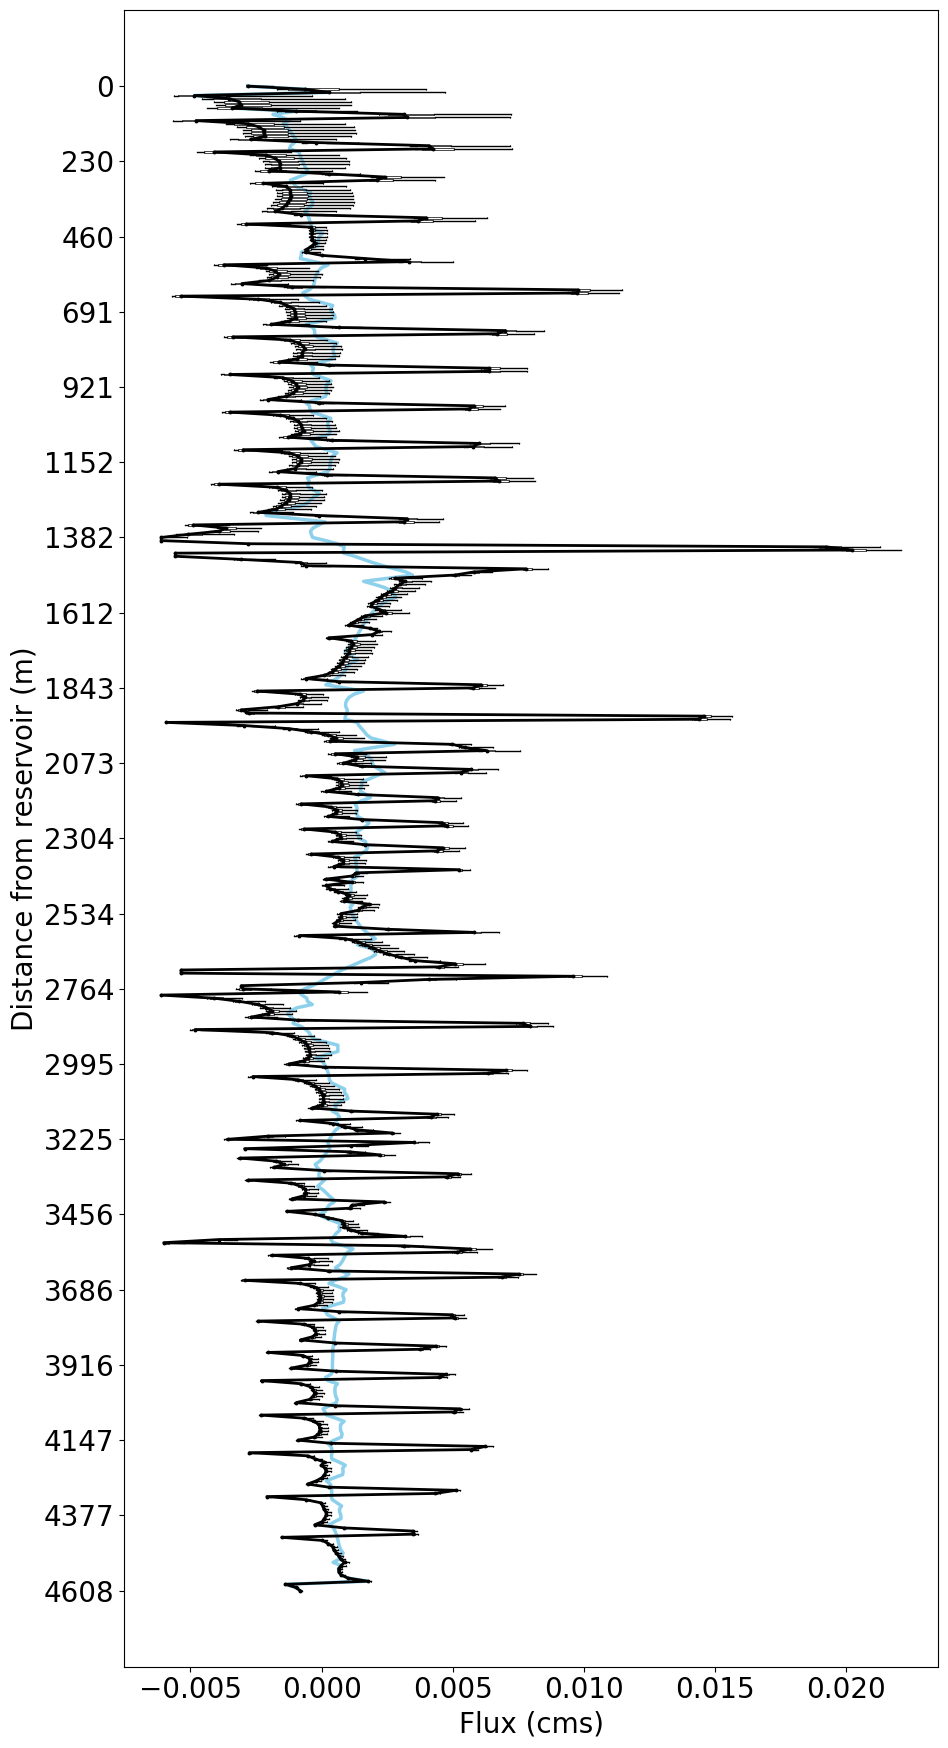

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 12,
})

date_col = df.columns[0]
loc_cols = [c for c in df.columns if c != date_col]
vals = df[loc_cols].apply(pd.to_numeric, errors="coerce")

dist_m = np.arange(len(loc_cols)) * 9.6
data = [vals[c].dropna().values for c in loc_cols]
medians = np.array([np.median(d) if len(d) else np.nan for d in data])

fig, ax = plt.subplots(figsize=(10, 18))

# ---------------------------------------------------
# 1. 대표값(median) 기반의 "하천형 참조 곡선" 만들기
# ---------------------------------------------------
curve_x = medians.copy()

# NaN 보간
valid = ~np.isnan(curve_x)
curve_x_interp = np.interp(dist_m, dist_m[valid], curve_x[valid])

# 이동평균 smoothing
window = 19   # 홀수 권장, 값이 커질수록 더 부드러워짐
kernel = np.ones(window) / window
curve_x_smooth = np.convolve(curve_x_interp, kernel, mode='same')

# 끝부분이 과하게 꺾이는 것 완화
pad = window // 2
curve_x_smooth[:pad] = curve_x_interp[:pad]
curve_x_smooth[-pad:] = curve_x_interp[-pad:]

# 참조 곡선 그리기
ax.plot(
    curve_x_smooth, dist_m,
    color='skyblue',
    linewidth=2.5,
    alpha=0.95,
    zorder=1
)

# ---------------------------------------------------
# 2. Boxplot
# ---------------------------------------------------
bp = ax.boxplot(
    data,
    vert=False,
    positions=dist_m,
    widths=5,
    whis=[5, 95],
    patch_artist=True,
    showfliers=False,
    manage_ticks=False,
    whiskerprops={'linewidth': 1.0, 'color': 'black'},
    medianprops={'linewidth': 1.0, 'color': 'black'},
    boxprops={'facecolor': 'white', 'edgecolor': 'black', 'linewidth': 0.5},
    capprops={'color': 'black', 'linewidth': 0.5}
)

# ---------------------------------------------------
# 3. 원래 median 연결선
# ---------------------------------------------------
ax.plot(
    medians, dist_m,
    c='k',
    linewidth=2.0,
    marker='o',
    markersize=1.8,
    zorder=3
)

# ---------------------------------------------------
# 4. 축 설정
# ---------------------------------------------------
ax.invert_yaxis()
ax.set_xlabel("Flux (cms)")
ax.set_ylabel("Distance from reservoir (m)")

n = len(dist_m)
step = max(1, n // 20)
tick_idx = np.arange(0, n, step)
ax.set_yticks(dist_m[tick_idx])
ax.set_yticklabels([f"{int(dist_m[i])}" for i in tick_idx])

plt.tight_layout()
plt.savefig('./Figure7b.tif', dpi=300)
plt.show()